In [5]:
from riboss.orfs import translate

In [8]:
na ="ATGGaT"

In [9]:
translate(na)

'MD'

In [15]:
! cd /projects/health_sciences/bms/biochemistry/lim_group/cslim/riboss/bin/sratoolkit.3.1.1-centos_linux64/

In [ ]:
!nano ~/.ba

In [ ]:
#DO NOT EXCEUTE
# 6 MBOct 7, 2024
#not working through link, need to be downloaded manually! wget https://www.arabidopsis.org/api/download-files/download?filePath=Genes/Araport11_genome_release/Araport11_GTF_genes_transposons.current.gtf.gz \
#-O ../ref/Araport11_GTF_genes_transposons.current.gtf.gz
!gunzip ../ref/TAIR10_chr_all.fas.gz

!wget https://www.arabidopsis.org/download/file?path=Genes/TAIR10_genome_release/TAIR10_chromosome_files/TAIR10_chr_all.fas.gz -O \
../ref/TAIR10_chr_all.fas.gz

! gtfToGenePred -genePredExt -ignoreGroupsWithoutExons ../ref/Araport11_GTF_genes_transposons.current.gtf.gz stdout \
| genePredToBed stdin ../ref/Araport11_GTF_genes_transposons.current.bed

! awk '$7!=$8' ../ref/Araport11_GTF_genes_transposons.current.bed > ../ref/Araport11_GTF_genes_transposons.current.pc.bed


! zcat ../ref/Araport11_GTF_genes_transposons.current.gtf.gz \
| grep -i 'uorf' | sed 's/uORF/exon/' \
| gtfToGenePred -genePredExt -ignoreGroupsWithoutExons stdin ../ref/Araport11_GTF_genes_transposons.current.uorfs.gp

#download DNA sequence (required for getting transcript (uORF) sequence by bedtools get fasta from bed file coordinates)
! wget https://www.arabidopsis.org/api/download-files/download?filePath=Sequences/Assemblies/TAIR9_chr_all.fas \
-O ../ref/TAIR9_chr_all.fas

In [1]:
import os
import pandas as pd
from riboss.wrapper import transcriptome_assembly

In [29]:
!ls -lh ../ref/Araport11_GTF_genes_transposons.current.gtf.gz

-rw-rw----+ 1 limch05p lx_limch05p 6.4M Jan 10 16:43 ../ref/Araport11_GTF_genes_transposons.current.gtf.gz


In [33]:
#convert gtf to genePred, genePred to bed

!gtfToGenePred -genePredExt -ignoreGroupsWithoutExons ../ref/Araport11_GTF_genes_transposons.current.gtf.gz stdout \
| genePredToBed stdin stdout \
| head

#output -chromosome, transcript start, transcript end, _, strandness, start codon, stop codon, _, exons, coordinates of the exons (relative to transcript)

Chr1	3630	5899	AT1G01010.1	0	+	3759	5630	0	6	283,281,120,390,153,461,	0,365,855,1075,1543,1808,
Chr1	6787	9130	AT1G01020.1	0	-	6914	8666	0	9	282,76,67,86,74,46,90,48,560,	0,369,596,776,974,1154,1448,1629,1783,
Chr1	6787	8737	AT1G01020.2	0	-	7314	8666	0	8	282,294,86,74,46,90,48,167,	0,369,776,974,1154,1448,1629,1783,
Chr1	6787	9130	AT1G01020.3	0	-	6914	8442	0	8	282,76,67,86,74,46,229,560,	0,369,596,776,974,1154,1448,1783,
Chr1	6787	9130	AT1G01020.4	0	-	6914	8442	0	8	282,76,67,86,74,46,229,537,	0,369,596,776,974,1154,1448,1806,
Chr1	6787	9130	AT1G01020.5	0	-	6914	8419	0	9	282,76,67,86,74,46,90,48,537,	0,369,596,776,974,1154,1448,1629,1806,
Chr1	6787	8737	AT1G01020.6	0	-	7314	8419	0	6	282,294,86,90,48,144,	0,369,776,1448,1629,1806,
Chr1	11648	13714	AT1G01030.1	0	-	11863	12940	0	2	1525,380,	0,1686,
Chr1	11648	13714	AT1G01030.2	0	-	11863	12940	0	3	706,750,380,	0,775,1686,
Chr1	23120	31227	AT1G01040.1	0	+	23518	31079	0	20	1331,114,211,395,220,173,123,161,234,151,183,162,96,629,98,191,906,165

In [8]:
#DO NOT EXECUTE to write the file
!gtfToGenePred -genePredExt -ignoreGroupsWithoutExons ../ref/Araport11_GTF_genes_transposons.current.gtf.gz stdout \
| genePredToBed stdin ../ref/Araport11_GTF_genes_transposons.current.anh.bed

Couldn't open ../ref/Araport11_GTF_genes_transposons.Oct2023.gtf.gz , Success


In [ ]:
#DO NOT EXECUTE
! zcat ../ref/Araport11_GTF_genes_transposons.current.gtf.gz \
| grep -i 'uorf' | sed 's/uORF/exon/' \
| gtfToGenePred -genePredExt -ignoreGroupsWithoutExons stdin stoud \
| genePredToBed stdin ../ref/Araport11_GTF_genes_transposons.current.uorfs.bed




In [42]:
#bedtools get fasta sequence for the regions corresponding to coordinates in input bed file
! bedtools getfasta -bed ../ref/Araport11_GTF_genes_transposons.current.pc.bed -fi ../ref/TAIR10_chr_all.fas -name |head

>AT1G01010.1::Chr1:3630-5899
AAATTATTAGATATACCAAACCAGAGAAAACAAATACATAATCGGAGAAATACAGATTACAGAGAGCGAGAGAGATCGACGGCGAAGCTCTTTACCCGGAAACCATTGAAATCGGACGGTTTAGTGAAAATGGAGGATCAAGTTGGGTTTGGGTTCCGTCCGAACGACGAGGAGCTCGTTGGTCACTATCTCCGTAACAAAATCGAAGGAAACACTAGCCGCGACGTTGAAGTAGCCATCAGCGAGGTCAACATCTGTAGCTACGATCCTTGGAACTTGCGCTGTAAGTTCCGAATTTTCTGAATTTCATTTGCAAGTAATCGATTTAGGTTTTTGATTTTAGGGTTTTTTTTTGTTTTGAACAGTCCAGTCAAAGTACAAATCGAGAGATGCTATGTGGTACTTCTTCTCTCGTAGAGAAAACAACAAAGGGAATCGACAGAGCAGGACAACGGTTTCTGGTAAATGGAAGCTTACCGGAGAATCTGTTGAGGTCAAGGACCAGTGGGGATTTTGTAGTGAGGGCTTTCGTGGTAAGATTGGTCATAAAAGGGTTTTGGTGTTCCTCGATGGAAGATACCCTGACAAAACCAAATCTGATTGGGTTATCCACGAGTTCCACTACGACCTCTTACCAGAACATCAGGTTTTCTTCTATTCATATATATATATATATATATATGTGGATATATATATATGTGGTTTCTGCTGATTCATAGTTAGAATTTGAGTTATGCAAATTAGAAACTATGTAATGTAACTCTATTTAGGTTCAGCAGCTATTTTAGGCTTAGCTTACTCTCACCAATGTTTTATACTGATGAACTTATGTGCTTACCTCCGGAAATTTTACAGAGGACATATGTCATCTGCAGACTTGAGTACAAGGGTGATGATGCGGACATTCTATCTGCTTATGCAATAGATCCCACTCCCGCTTTTGTCCCCAATATGACTAGTAGTGCAGGTTC

In [ ]:
#DO NOT EXCECUTE
! bedtools getfasta -bed ../ref/Araport11_GTF_genes_transposons.current.bed -fi ../ref/TAIR10_chr_all.fas \
-s -split -name -fo /ref/Araport11_GTF_genes_transposons.current.pc.bed

In [1]:
!head ../ref/Araport11_GTF_genes_transposons.current.pc.bed

Chr1	3630	5899	AT1G01010.1	0	+	3759	5630	0	6	283,281,120,390,153,461,	0,365,855,1075,1543,1808,
Chr1	6787	9130	AT1G01020.1	0	-	6914	8666	0	9	282,76,67,86,74,46,90,48,560,	0,369,596,776,974,1154,1448,1629,1783,
Chr1	6787	8737	AT1G01020.2	0	-	7314	8666	0	8	282,294,86,74,46,90,48,167,	0,369,776,974,1154,1448,1629,1783,
Chr1	6787	9130	AT1G01020.3	0	-	6914	8442	0	8	282,76,67,86,74,46,229,560,	0,369,596,776,974,1154,1448,1783,
Chr1	6787	9130	AT1G01020.4	0	-	6914	8442	0	8	282,76,67,86,74,46,229,537,	0,369,596,776,974,1154,1448,1806,
Chr1	6787	9130	AT1G01020.5	0	-	6914	8419	0	9	282,76,67,86,74,46,90,48,537,	0,369,596,776,974,1154,1448,1629,1806,
Chr1	6787	8737	AT1G01020.6	0	-	7314	8419	0	6	282,294,86,90,48,144,	0,369,776,1448,1629,1806,
Chr1	11648	13714	AT1G01030.1	0	-	11863	12940	0	2	1525,380,	0,1686,
Chr1	11648	13714	AT1G01030.2	0	-	11863	12940	0	3	706,750,380,	0,775,1686,
Chr1	23120	31227	AT1G01040.1	0	+	23518	31079	0	20	1331,114,211,395,220,173,123,161,234,151,183,162,96,629,98,191,906,165

In [3]:
!head ../ref/Araport11_GTF_genes_transposons.current.pc.fa

>AT1G01010.1::Chr1:3630-5899(+)
AAATTATTAGATATACCAAACCAGAGAAAACAAATACATAATCGGAGAAATACAGATTACAGAGAGCGAGAGAGATCGACGGCGAAGCTCTTTACCCGGAAACCATTGAAATCGGACGGTTTAGTGAAAATGGAGGATCAAGTTGGGTTTGGGTTCCGTCCGAACGACGAGGAGCTCGTTGGTCACTATCTCCGTAACAAAATCGAAGGAAACACTAGCCGCGACGTTGAAGTAGCCATCAGCGAGGTCAACATCTGTAGCTACGATCCTTGGAACTTGCGCTTCCAGTCAAAGTACAAATCGAGAGATGCTATGTGGTACTTCTTCTCTCGTAGAGAAAACAACAAAGGGAATCGACAGAGCAGGACAACGGTTTCTGGTAAATGGAAGCTTACCGGAGAATCTGTTGAGGTCAAGGACCAGTGGGGATTTTGTAGTGAGGGCTTTCGTGGTAAGATTGGTCATAAAAGGGTTTTGGTGTTCCTCGATGGAAGATACCCTGACAAAACCAAATCTGATTGGGTTATCCACGAGTTCCACTACGACCTCTTACCAGAACATCAGAGGACATATGTCATCTGCAGACTTGAGTACAAGGGTGATGATGCGGACATTCTATCTGCTTATGCAATAGATCCCACTCCCGCTTTTGTCCCCAATATGACTAGTAGTGCAGGTTCTGTGGTCAACCAATCACGTCAACGAAATTCAGGATCTTACAACACTTACTCTGAGTATGATTCAGCAAATCATGGCCAGCAGTTTAATGAAAACTCTAACATTATGCAGCAGCAACCACTTCAAGGATCATTCAACCCTCTCCTTGAGTATGATTTTGCAAATCACGGCGGTCAGTGGCTGAGTGACTATATCGACCTGCAACAGCAAGTTCCTTACTTGGCACCTTATGAAAATGAGTCGGAGATGATTTGGAAGCATGTGATTGAAGAAAATTTTGAGTTTTTGGT

In [7]:
!awk '{print $4, $3-$2}' ../ref/Araport11_GTF_genes_transposons.current.pc.bed | head -5

AT1G01010.1 2269
AT1G01020.1 2343
AT1G01020.2 1950
AT1G01020.3 2343
AT1G01020.4 2343


In [6]:
!awk '{print length ($1)}' ../ref/Araport11_GTF_genes_transposons.current.pc.fa | head -5

31
1688
31
1329
31


In [10]:
!echo 283,281,120,390,153,461 | sed 's/,/+/g' 

283+281+120+390+153+461


In [11]:
283+281+120+390+153+461

1688

In [ ]:
#
!head ../ref/Araport11_GTF_genes_transposons.current.bed
#showing non-coding uORFs
! awk '$7==$8' ../ref/Araport11_GTF_genes_transposons.current.bed
! awk '$7!=$8' ../ref/Araport11_GTF_genes_transposons.current.bed | wc -l
#showing coding uORFs
! awk '$7!=$8' ../ref/Araport11_GTF_genes_transposons.current.bed
! awk '$7==$8' ../ref/Araport11_GTF_genes_transposons.current.bed | wc -l

In [37]:
! awk '$7!=$8' ../ref/Araport11_GTF_genes_transposons.current.bed > ../ref/Araport11_GTF_genes_transposons.current.pc.bed 

In [39]:
! wc -l ../ref/Araport11_GTF_genes_transposons.current.pc.bed

48270 ../ref/Araport11_GTF_genes_transposons.current.pc.bed


In [40]:
! head ../ref/Araport11_GTF_genes_transposons.current.pc.bed

Chr1	3630	5899	AT1G01010.1	0	+	3759	5630	0	6	283,281,120,390,153,461,	0,365,855,1075,1543,1808,
Chr1	6787	9130	AT1G01020.1	0	-	6914	8666	0	9	282,76,67,86,74,46,90,48,560,	0,369,596,776,974,1154,1448,1629,1783,
Chr1	6787	8737	AT1G01020.2	0	-	7314	8666	0	8	282,294,86,74,46,90,48,167,	0,369,776,974,1154,1448,1629,1783,
Chr1	6787	9130	AT1G01020.3	0	-	6914	8442	0	8	282,76,67,86,74,46,229,560,	0,369,596,776,974,1154,1448,1783,
Chr1	6787	9130	AT1G01020.4	0	-	6914	8442	0	8	282,76,67,86,74,46,229,537,	0,369,596,776,974,1154,1448,1806,
Chr1	6787	9130	AT1G01020.5	0	-	6914	8419	0	9	282,76,67,86,74,46,90,48,537,	0,369,596,776,974,1154,1448,1629,1806,
Chr1	6787	8737	AT1G01020.6	0	-	7314	8419	0	6	282,294,86,90,48,144,	0,369,776,1448,1629,1806,
Chr1	11648	13714	AT1G01030.1	0	-	11863	12940	0	2	1525,380,	0,1686,
Chr1	11648	13714	AT1G01030.2	0	-	11863	12940	0	3	706,750,380,	0,775,1686,
Chr1	23120	31227	AT1G01040.1	0	+	23518	31079	0	20	1331,114,211,395,220,173,123,161,234,151,183,162,96,629,98,191,906,165

In [2]:
#Build STAR index for the human transcriptome
import os
from riboss.wrapper import build_star_index

In [3]:
from riboss.wrapper import transcriptome_assembly

In [ ]:
#STAR requires an indexed fasta ref for alignment
tx_assembly = '../ref/Araport11_GTF_genes_transposons.current.pc.fa'
index = os.path.split(tx_assembly)[0] + '/' + '.'.join(os.path.split(tx_assembly)[1].split(os.extsep)[:-1])

#
build_star_index(tx_assembly, index, delim=':')

In [4]:
from riboss.orfs import orf_finder
import pyranges as pr
import pandas as pd

annotation='../ref/Araport11_GTF_genes_transposons.current.pc.bed'
fasta='../ref/TAIR10_chr_all.fas'

cdc_range, df =orf_finder(annotation, fasta, ncrna=False, outdir=None, start_codon=["ATG","ACG","CTG","GTG","TTG"])

finding all ORFs  
converting coordin
converting coordin
INFO:root:found 2421284 ORFs in 7 min 26 s
INFO:root:saved sequences as ../ref/Araport11_GTF_genes_transposons.current.pc.transcripts.fa
INFO:root:saved sequences as ../ref/Araport11_GTF_genes_transposons.current.pc.gp
INFO:root:saved sequences as ../ref/Araport11_GTF_genes_transposons.current.pc.orf_finder.pkl.gz
INFO:root:saved CDS range as ../ref/Araport11_GTF_genes_transposons.current.pc.cds_range.txt


In [20]:
df

,Chromosome,tid,Strand,ORF_range,start_codon,ORF_start,ORF_end,Start,End,ORF_type,ORF_length
0,Chr1,AT1G01010.1,+,"[129, 1419]",ATG,129,1419,3759.0,5630.0,mORF,1290
276,Chr1,AT1G01040.1,+,"[398, 6128]",ATG,398,6128,23518.0,31079.0,mORF,5730
420,Chr1,AT1G01040.2,+,"[103, 5836]",ATG,103,5836,23518.0,31079.0,mORF,5733
1309,Chr1,AT1G01110.1,+,"[754, 1849]",ATG,754,1849,53021.0,54494.0,mORF,1095
1329,Chr1,AT1G01110.2,+,"[286, 1870]",ATG,286,1870,52238.0,54494.0,mORF,1584
...,...,...,...,...,...,...,...,...,...,...,...
1807683,ChrM,ATMG00570.1,-,"[839, 842]",ATG,839,842,218904.0,218907.0,dORF,3
1807898,ChrM,ATMG00650.1,-,"[10, 130]",ATG,10,130,361809.0,361929.0,dORF,120
1807899,ChrM,ATMG00650.1,-,"[67, 130]",ATG,67,130,361809.0,361872.0,dORF,63
1807900,ChrM,ATMG00650.1,-,"[113, 215]",ATG,113,215,361724.0,361826.0,dORF,102


In [22]:
df[df.tid=='AT1G01010.1']

,Chromosome,tid,Strand,ORF_range,start_codon,ORF_start,ORF_end,Start,End,ORF_type,ORF_length
0,Chr1,AT1G01010.1,+,"[129, 1419]",ATG,129,1419,3759.0,5630.0,mORF,1290
29,Chr1,AT1G01010.1,+,"[1461, 1521]",ATG,1461,1521,5672.0,5732.0,dORF,60
30,Chr1,AT1G01010.1,+,"[1538, 1544]",ATG,1538,1544,5749.0,5755.0,dORF,6
31,Chr1,AT1G01010.1,+,"[1579, 1687]",ATG,1579,1687,5790.0,5898.0,dORF,108
32,Chr1,AT1G01010.1,+,"[1597, 1687]",ATG,1597,1687,5808.0,5898.0,dORF,90
33,Chr1,AT1G01010.1,+,"[1616, 1622]",ATG,1616,1622,5827.0,5833.0,dORF,6


In [25]:
df[df.ORF_type=='uORF']

,Chromosome,tid,Strand,ORF_range,start_codon,ORF_start,ORF_end,Start,End,ORF_type,ORF_length
275,Chr1,AT1G01040.1,+,"[368, 383]",ATG,368,383,23488.0,23503.0,uORF,15
419,Chr1,AT1G01040.2,+,"[73, 88]",ATG,73,88,23488.0,23503.0,uORF,15
1328,Chr1,AT1G01110.2,+,"[16, 37]",ATG,16,37,51968.0,51989.0,uORF,21
1674,Chr1,AT1G01180.1,+,"[2, 29]",ATG,2,29,75391.0,75418.0,uORF,27
1675,Chr1,AT1G01180.1,+,"[15, 21]",ATG,15,21,75404.0,75410.0,uORF,6
...,...,...,...,...,...,...,...,...,...,...,...
1805563,Chr5,AT5G67580.2,-,"[65, 245]",ATG,65,245,26957023.0,26957660.0,uORF,180
1805564,Chr5,AT5G67580.2,-,"[123, 186]",ATG,123,186,26957082.0,26957602.0,uORF,63
1805692,Chr5,AT5G67620.1,-,"[155, 188]",ATG,155,188,26965822.0,26965855.0,uORF,33
1805693,Chr5,AT5G67620.1,-,"[158, 188]",ATG,158,188,26965822.0,26965852.0,uORF,30


In [28]:
df.value_counts('ORF_type')

ORF_type
dORF    389949
oORF    100733
uORF     77522
mORF     48148
Name: count, dtype: int64

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df.value_counts(['tid','ORF_type']).reset_index()

,tid,ORF_type,count
0,AT1G55860.1,oORF,181
1,AT1G67120.2,dORF,145
2,AT1G67120.1,dORF,144
3,AT2G45540.2,dORF,122
4,AT3G44690.1,dORF,119
...,...,...,...
127306,AT3G54500.1,mORF,1
127307,AT3G54500.1,uORF,1
127308,AT3G54500.2,mORF,1
127309,AT1G16515.1,mORF,1


In [ ]:
df.groupby('tid')['ORF_type'].agg('count')

<Axes: xlabel='ORF_type', ylabel='ORF_length'>

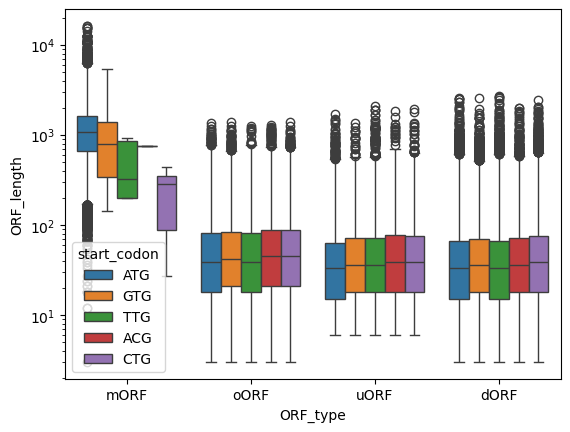

In [5]:
sns.boxplot(data=df, x='ORF_type', y='ORF_length', hue='start_codon', log_scale=True)

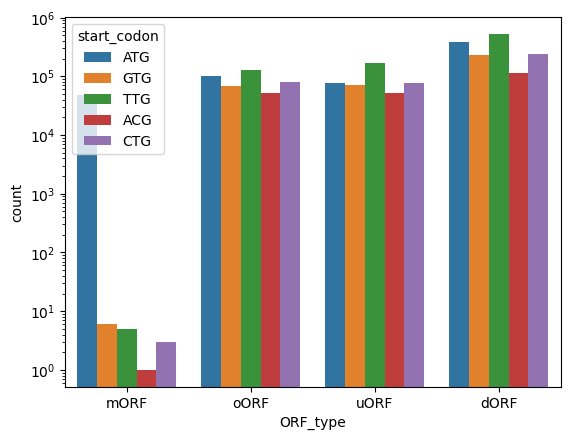

In [11]:
sns.countplot(data=df, x='ORF_type', hue='start_codon')
plt.yscale('log')

<Axes: xlabel='ORF_type', ylabel='count'>

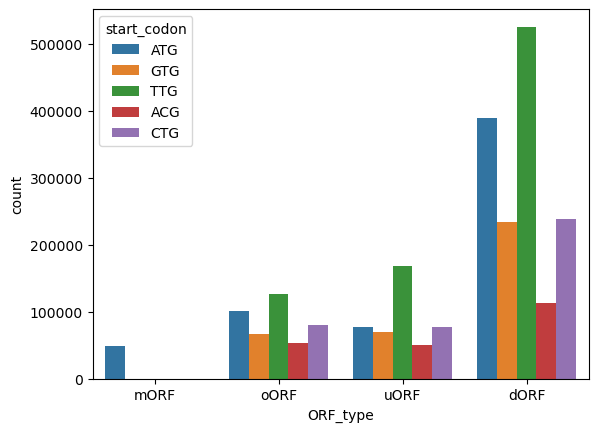

In [12]:
sns.countplot(data=df, x='ORF_type', hue='start_codon')

In [6]:
df[(df.ORF_type=='mORF') & (df.start_codon=='CTG')]

,Chromosome,tid,Strand,ORF_range,start_codon,ORF_start,ORF_end,Start,End,ORF_type,ORF_length
5044377,Chr4,AT4G28755.1,+,"[0, 285]",CTG,0,285,14203625.0,14204377.0,mORF,285
6947386,Chr5,AT5G66335.1,+,"[0, 435]",CTG,0,435,26501530.0,26501965.0,mORF,435
4468350,Chr4,AT4G09355.1,-,"[0, 27]",CTG,0,27,5937724.0,5937751.0,mORF,27


In [41]:
df.groupby(['ORF_type'])['ORF_length'].describe()

,count,mean,std,min,25%,50%,75%,max
ORF_type,,,,,,,,
dORF,389949.0,50.976828,64.166802,3.0,15.0,33.0,66.0,5358.0
mORF,48148.0,1299.241692,982.148623,3.0,660.0,1086.0,1629.0,16203.0
oORF,100733.0,60.160791,62.149678,3.0,18.0,39.0,81.0,1341.0
uORF,77522.0,49.239364,53.921785,6.0,15.0,33.0,63.0,1689.0


In [44]:
df.groupby(['ORF_type'])['ORF_length'].agg('mean')

ORF_type
dORF      50.976828
mORF    1299.241692
oORF      60.160791
uORF      49.239364
Name: ORF_length, dtype: float64

In [39]:
df['ORF_type'].describe()

count     616352
unique         4
top         dORF
freq      389949
Name: ORF_type, dtype: object

In [43]:
df['ORF_length'].describe()

count    616352.000000
mean        149.770850
std         436.953564
min           3.000000
25%          18.000000
50%          39.000000
75%          84.000000
max       16203.000000
Name: ORF_length, dtype: float64

In [ ]:
#COMMAND LINES
#commpare -12 file 1 file 2
#files must be sorted before being compared
#the same bw file 1 and 2 
comm -12 <(sort Araport11_GTF_genes_transposons.Oct2023.uorfs.gp) <(sort Araport11_GTF_genes_transposons.current.uorfs.gp) | wc -l

#unique in file 1
comm -23 <(sort Araport11_GTF_genes_transposons.Oct2023.uorfs.gp) <(sort Araport11_GTF_genes_transposons.current.uorfs.gp) | wc -l

#unique in file 2
comm -13 <(sort Araport11_GTF_genes_transposons.Oct2023.uorfs.gp) <(sort Araport11_GTF_genes_transposons.current.uorfs.gp) | wc -l
